# LEAF PAI vs GNSS-T nVOD & nVOD vs stem water potential (met filtered)

**LEAF × nVOD** — Pairs **hemi-hi LEAF at 20:00 UTC** with **daily** nVOD on the same calendar date (predawn / afternoon windows per `gnss_vod.py`). Joint QC: `quality_good` and a dry **nVOD** aggregation window.

**nVOD × SWP** — Same calendar date, no LEAF filter: **predawn nVOD** vs **mean SWP 04:00–05:59 UTC**, and **afternoon nVOD** vs **mean SWP 19:00–20:59 UTC**. Joint QC: both the **nVOD** window and the **SWP** window must pass the precip / RH screen (independent windows).

### Window definitions

- nVOD: `PREDAWN_HOURS`, `AFTERNOON_HOURS` (UTC), aligned with `src/proximal_rs/gnss_vod.py`.
- SWP: `SWP_PREDAWN_HOURS` (04–06 UTC), `SWP_EVENING_HOURS` (19–21 UTC).

At the end: **PAI–structure correction** for **evening nVOD** (19–21 UTC, 30 min stack) vs **total PAI** from LEAF, then correlation of **raw vs residual** nVOD with **predawn SWP**.

Adjust `REFERENCE_HEIGHT`, `GPS_COL_*`, `SWP_COL`, and thresholds in the setup cell.

In [44]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
import matplotlib.cm as cm


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "data" / "processed").is_dir():
            return p
        p = p.parent
    return Path.cwd().resolve()


ROOT = _repo_root()
PROC = ROOT / "data" / "processed"
YEAR = 2025

# LEAF layer for PAI (one height per scan)
REFERENCE_HEIGHT = 20.0
SCAN_HOUR = 20
PAI_COL = "WeightedPAI"

# GNSS receiver (below-canopy vs GPS1)
GPS_COL_PRE = "nvod_predawn_gps3"
GPS_COL_AFT = "nvod_afternoon_gps3"

# Same order of magnitude as leaf_batch_processing_dehar.ipynb
PRECIP_THRESH_MM = 0.1
RH_THRESH_PCT = 95.0

# GNSS aggregation windows (UTC) — keep in sync with src/proximal_rs/gnss_vod.py
PREDAWN_HOURS = (1, 5)      # 01:00 <= t < 05:00
AFTERNOON_HOURS = (12, 16)  # 12:00 <= t < 16:00

# SWP: predawn sampling window & evening (around 20:00 LEAF scan)
SWP_PREDAWN_HOURS = (4, 6)   # 04:00 <= t < 06:00
SWP_EVENING_HOURS = (19, 21)  # 19:00 <= t < 21:00

# Evening nVOD window aligned with 20:00 LEAF scan (same as SWP_EVENING_HOURS)
EVENING_VOD_LEAF_HOURS = SWP_EVENING_HOURS  # 19:00 <= t < 21:00 UTC

# Tree column in swp_dehar_15min.csv
SWP_COL = "swp_mpa_h10545"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.dpi": 120,
})

print("ROOT", ROOT)

ROOT /mnt/data/lk1167/projects/dehar-spac


In [45]:
def _read_ts_datetime(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=["datetime"], index_col="datetime")
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    return df.sort_index()


precip_path = PROC / "atmosphere_soil" / "HARTHM_2025_Precipitation_30min_UTC.csv"
precip_raw = pd.read_csv(precip_path)
precip_raw["datetime"] = pd.to_datetime(
    precip_raw["From"].str.replace("Z", "+00:00", regex=False), utc=True
)
precip = precip_raw.set_index("datetime")[["Precipitation_Sum_mm"]].sort_index()

meteo = _read_ts_datetime(PROC / "atmosphere_soil" / "meteo_dehar_30min.csv")

vod_daily = _read_ts_datetime(PROC / "proximal_rs" / "gnss_vod" / "gnss_vod_dehar_daily.csv")

swp = _read_ts_datetime(PROC / "physiology" / "stemwater_potential" / "swp_dehar_15min.csv")
num_cols = [c for c in swp.columns if swp[c].dtype.kind in "fiu"]
SWP_MEAS_COL = SWP_COL if SWP_COL in swp.columns else (num_cols[0] if num_cols else swp.columns[0])

leaf_pq = PROC / "proximal_rs" / "leaf" / "leaf_hemi_hi_2025.parquet"
leaf = pd.read_parquet(leaf_pq, columns=[
    "datetime", "scan_hour", "height", PAI_COL,
    "quality_good", "flag_rain", "flag_humid", "precip_mm", "rh_pct",
])
leaf["datetime"] = pd.to_datetime(leaf["datetime"], utc=True)

if GPS_COL_PRE not in vod_daily.columns:
    GPS_COL_PRE, GPS_COL_AFT = "nvod_predawn_gps1", "nvod_afternoon_gps1"

if "gps3" in GPS_COL_PRE.lower():
    NVOD_30MIN_COL = "nvod_gps3"
elif "gps5" in GPS_COL_PRE.lower():
    NVOD_30MIN_COL = "nvod_gps5"
else:
    NVOD_30MIN_COL = "nvod_gps1"

vod_30 = _read_ts_datetime(PROC / "proximal_rs" / "gnss_vod" / "gnss_vod_dehar_30min.csv")
if NVOD_30MIN_COL not in vod_30.columns:
    NVOD_30MIN_COL = [c for c in vod_30.columns if c.startswith("nvod_")][0]

print("precip", precip.shape, "meteo", meteo.shape, "vod_daily", vod_daily.shape, "vod_30", vod_30.shape, "swp", swp.shape, SWP_MEAS_COL, NVOD_30MIN_COL)

precip (17520, 1) meteo (17520, 6) vod_daily (237, 12) vod_30 (9480, 3) swp (19148, 3) swp_mpa_h10545 nvod_gps3


In [46]:
def _hour_mask(idx: pd.DatetimeIndex, window: tuple[int, int]) -> np.ndarray:
    h = idx.hour.values
    a, b = window
    return (h >= a) & (h < b)


def daily_window_stats(
    p: pd.DataFrame,
    m: pd.DataFrame,
    window: tuple[int, int],
    year: int,
) -> pd.DataFrame:
    """Per calendar day: precip sum and max RH inside UTC hour window."""
    px = p[p.index.year == year]
    mx = m[m.index.year == year]
    mask_p = _hour_mask(px.index, window)
    mask_m = _hour_mask(mx.index, window)
    subp = px.loc[mask_p]
    subm = mx.loc[mask_m]
    pr = subp.groupby(subp.index.normalize())["Precipitation_Sum_mm"].sum()
    rh = subm.groupby(subm.index.normalize())["rh_pct"].max()
    out = pd.DataFrame({"precip_sum_mm": pr, "rh_max": rh})
    return out


def _add_met_ok(dfm: pd.DataFrame) -> pd.DataFrame:
    dfm = dfm.copy()
    dfm["wet_rain"] = dfm["precip_sum_mm"] >= PRECIP_THRESH_MM
    dfm["wet_rh"] = dfm["rh_max"] >= RH_THRESH_PCT
    dfm["window_ok"] = (
        dfm["precip_sum_mm"].notna()
        & dfm["rh_max"].notna()
        & ~dfm["wet_rain"]
        & ~dfm["wet_rh"]
    )
    return dfm


predawn_met = _add_met_ok(daily_window_stats(precip, meteo, PREDAWN_HOURS, YEAR))
afternoon_met = _add_met_ok(daily_window_stats(precip, meteo, AFTERNOON_HOURS, YEAR))
predawn_met = predawn_met.rename(columns={"window_ok": "vod_window_ok"})
afternoon_met = afternoon_met.rename(columns={"window_ok": "vod_window_ok"})

swp_predawn_met = _add_met_ok(daily_window_stats(precip, meteo, SWP_PREDAWN_HOURS, YEAR))
swp_evening_met = _add_met_ok(daily_window_stats(precip, meteo, SWP_EVENING_HOURS, YEAR))

print(
    "predawn met days", len(predawn_met), "afternoon", len(afternoon_met),
    "swp_pre", len(swp_predawn_met), "swp_eve", len(swp_evening_met),
)

predawn met days 365 afternoon 365 swp_pre 365 swp_eve 365


In [47]:
# One row per LEAF scan at 20:00, reference height
lf = leaf[
    (leaf["datetime"].dt.year == YEAR)
    & (leaf["scan_hour"] == SCAN_HOUR)
    & np.isclose(leaf["height"], REFERENCE_HEIGHT)
].drop_duplicates("datetime", keep="last")

lf = lf.set_index("datetime").sort_index()
lf["date"] = lf.index.normalize()

vod_y = vod_daily[vod_daily.index.year == YEAR].copy()
vod_y["date"] = vod_y.index.normalize()

base = lf[["date", PAI_COL, "quality_good", "flag_rain", "flag_humid"]].copy()
base = base.rename(columns={PAI_COL: "pai"})

swp_y = swp[swp.index.year == YEAR]
m_swp_pre = _hour_mask(swp_y.index, SWP_PREDAWN_HOURS)
m_swp_eve = _hour_mask(swp_y.index, SWP_EVENING_HOURS)
swp_pre_daily = (
    swp_y.loc[m_swp_pre, SWP_MEAS_COL]
    .groupby(swp_y.loc[m_swp_pre].index.normalize())
    .mean()
    .rename("swp_predawn_mpa")
)
swp_eve_daily = (
    swp_y.loc[m_swp_eve, SWP_MEAS_COL]
    .groupby(swp_y.loc[m_swp_eve].index.normalize())
    .mean()
    .rename("swp_evening_mpa")
)

merged_pre = base.merge(
    vod_y[["date", GPS_COL_PRE]].rename(columns={GPS_COL_PRE: "nvod_predawn"}),
    on="date",
    how="inner",
)
merged_pre = merged_pre.merge(
    predawn_met[["vod_window_ok", "precip_sum_mm", "rh_max"]].rename(
        columns={
            "vod_window_ok": "vod_predawn_window_ok",
            "precip_sum_mm": "precip_predawn_mm",
            "rh_max": "rh_max_predawn",
        }
    ),
    left_on="date",
    right_index=True,
    how="left",
)

merged_aft = base.merge(
    vod_y[["date", GPS_COL_AFT]].rename(columns={GPS_COL_AFT: "nvod_afternoon"}),
    on="date",
    how="inner",
)
merged_aft = merged_aft.merge(
    afternoon_met[["vod_window_ok", "precip_sum_mm", "rh_max"]].rename(
        columns={
            "vod_window_ok": "vod_afternoon_window_ok",
            "precip_sum_mm": "precip_afternoon_mm",
            "rh_max": "rh_max_afternoon",
        }
    ),
    left_on="date",
    right_index=True,
    how="left",
)

# nVOD × SWP (calendar date only; met QC on both windows)
nvod_swp_pre = (
    vod_y[["date", GPS_COL_PRE]]
    .rename(columns={GPS_COL_PRE: "nvod_predawn"})
    .merge(swp_pre_daily.rename_axis("date").reset_index(), on="date", how="inner")
)
nvod_swp_pre = nvod_swp_pre.merge(
    predawn_met[["vod_window_ok", "precip_sum_mm", "rh_max"]].rename(
        columns={
            "vod_window_ok": "vod_predawn_window_ok",
            "precip_sum_mm": "precip_predawn_mm",
            "rh_max": "rh_max_predawn",
        }
    ),
    left_on="date",
    right_index=True,
    how="left",
)
nvod_swp_pre = nvod_swp_pre.merge(
    swp_predawn_met[["window_ok", "precip_sum_mm", "rh_max"]].rename(
        columns={
            "window_ok": "swp_predawn_window_ok",
            "precip_sum_mm": "precip_swp_predawn_mm",
            "rh_max": "rh_max_swp_predawn",
        }
    ),
    left_on="date",
    right_index=True,
    how="left",
)

nvod_swp_aft_eve = (
    vod_y[["date", GPS_COL_AFT]]
    .rename(columns={GPS_COL_AFT: "nvod_afternoon"})
    .merge(swp_eve_daily.rename_axis("date").reset_index(), on="date", how="inner")
)
nvod_swp_aft_eve = nvod_swp_aft_eve.merge(
    afternoon_met[["vod_window_ok", "precip_sum_mm", "rh_max"]].rename(
        columns={
            "vod_window_ok": "vod_afternoon_window_ok",
            "precip_sum_mm": "precip_afternoon_mm",
            "rh_max": "rh_max_afternoon",
        }
    ),
    left_on="date",
    right_index=True,
    how="left",
)
nvod_swp_aft_eve = nvod_swp_aft_eve.merge(
    swp_evening_met[["window_ok", "precip_sum_mm", "rh_max"]].rename(
        columns={
            "window_ok": "swp_evening_window_ok",
            "precip_sum_mm": "precip_swp_evening_mm",
            "rh_max": "rh_max_swp_evening",
        }
    ),
    left_on="date",
    right_index=True,
    how="left",
)

merged_pre["use_predawn"] = merged_pre["quality_good"] & merged_pre["vod_predawn_window_ok"].fillna(False)
merged_aft["use_afternoon"] = merged_aft["quality_good"] & merged_aft["vod_afternoon_window_ok"].fillna(False)
nvod_swp_pre["use_nvod_swp_predawn"] = (
    nvod_swp_pre["vod_predawn_window_ok"].fillna(False)
    & nvod_swp_pre["swp_predawn_window_ok"].fillna(False)
)
nvod_swp_aft_eve["use_nvod_swp_afternoon_evening"] = (
    nvod_swp_aft_eve["vod_afternoon_window_ok"].fillna(False)
    & nvod_swp_aft_eve["swp_evening_window_ok"].fillna(False)
)

print("paired scans (predawn nvod non-null):", merged_pre["nvod_predawn"].notna().sum())
print("  use_predawn (joint filter):", merged_pre["use_predawn"].sum())
print("paired scans (afternoon nvod non-null):", merged_aft["nvod_afternoon"].notna().sum())
print("  use_afternoon (joint filter):", merged_aft["use_afternoon"].sum())
print("days (predawn nVOD + predawn SWP):", len(nvod_swp_pre))
print("  use_nvod_swp_predawn (both windows dry):", nvod_swp_pre["use_nvod_swp_predawn"].sum())
print("days (afternoon nVOD + evening SWP):", len(nvod_swp_aft_eve))
print("  use_nvod_swp_afternoon_evening:", nvod_swp_aft_eve["use_nvod_swp_afternoon_evening"].sum())

paired scans (predawn nvod non-null): 199
  use_predawn (joint filter): 56
paired scans (afternoon nvod non-null): 211
  use_afternoon (joint filter): 148
days (predawn nVOD + predawn SWP): 195
  use_nvod_swp_predawn (both windows dry): 57
days (afternoon nVOD + evening SWP): 194
  use_nvod_swp_afternoon_evening: 137


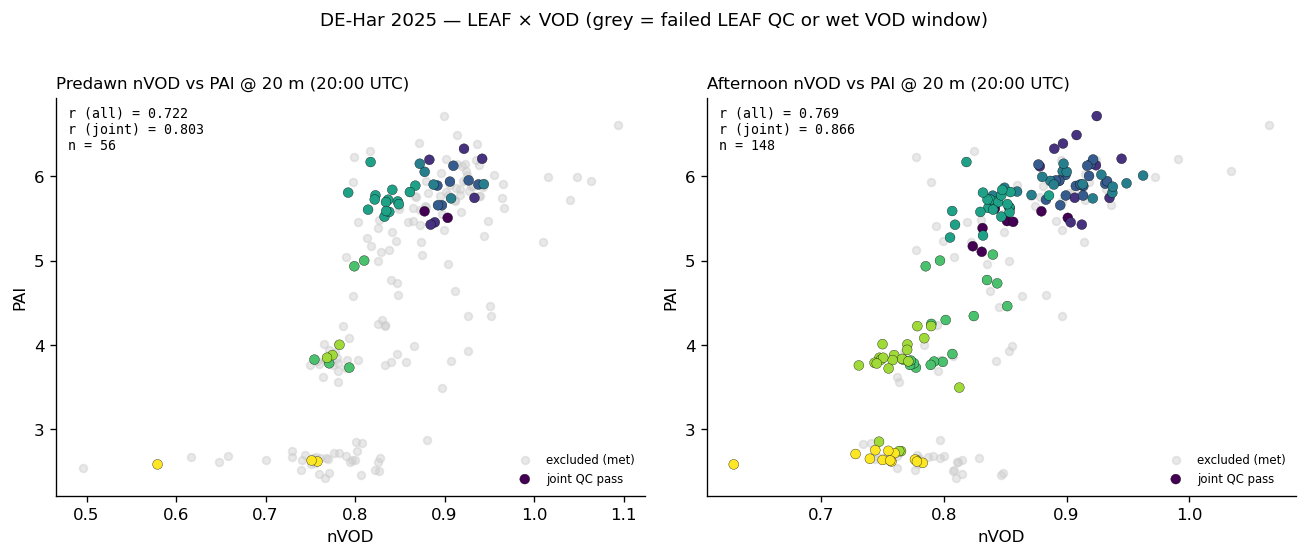

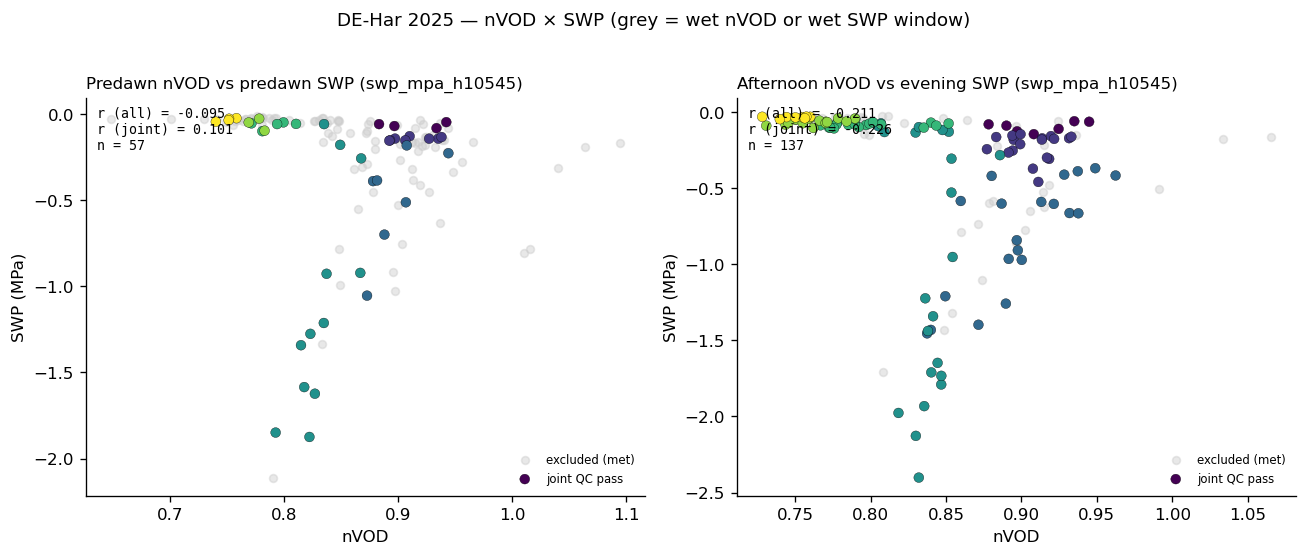

In [48]:
def _pearson(x, y):
    m = x.notna() & y.notna()
    if m.sum() < 3:
        return float("nan")
    return float(np.corrcoef(x[m], y[m])[0, 1])


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, df, xcol, okcol, title in [
    (
        axes[0],
        merged_pre,
        "nvod_predawn",
        "use_predawn",
        f"Predawn nVOD vs PAI @ {REFERENCE_HEIGHT:g} m (20:00 UTC)",
    ),
    (
        axes[1],
        merged_aft,
        "nvod_afternoon",
        "use_afternoon",
        f"Afternoon nVOD vs PAI @ {REFERENCE_HEIGHT:g} m (20:00 UTC)",
    ),
]:
    ex = df[~df[okcol]]
    ok = df[df[okcol]]
    ax.scatter(
        ex[xcol], ex["pai"], c="#cccccc", s=22, alpha=0.45, label="excluded (met)",
    )
    months = ok["date"].dt.month
    norm = Normalize(vmin=int(months.min()), vmax=int(months.max()))
    sc = ax.scatter(
        ok[xcol],
        ok["pai"],
        c=months,
        cmap="viridis",
        norm=norm,
        s=35,
        edgecolors="k",
        linewidths=0.2,
        label="joint QC pass",
    )
    ax.set_xlabel("nVOD")
    ax.set_ylabel("PAI")
    ax.set_title(title, fontsize=10, loc="left")
    r_all = _pearson(df[xcol], df["pai"])
    r_ok = _pearson(ok[xcol], ok["pai"])
    ax.text(
        0.02,
        0.98,
        f"r (all) = {r_all:.3f}\nr (joint) = {r_ok:.3f}\nn = {ok.shape[0]}",
        transform=ax.transAxes,
        va="top",
        fontsize=8,
        family="monospace",
    )
    ax.legend(loc="lower right", fontsize=7)

fig.suptitle(
    f"DE-Har {YEAR} — LEAF × VOD (grey = failed LEAF QC or wet VOD window)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

# nVOD vs SWP: joint met on the nVOD window and on the SWP window
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, df, xcol, ycol, okcol, title in [
    (
        axes2[0],
        nvod_swp_pre,
        "nvod_predawn",
        "swp_predawn_mpa",
        "use_nvod_swp_predawn",
        f"Predawn nVOD vs predawn SWP ({SWP_MEAS_COL})",
    ),
    (
        axes2[1],
        nvod_swp_aft_eve,
        "nvod_afternoon",
        "swp_evening_mpa",
        "use_nvod_swp_afternoon_evening",
        f"Afternoon nVOD vs evening SWP ({SWP_MEAS_COL})",
    ),
]:
    ex = df[~df[okcol]]
    ok = df[df[okcol]]
    ax.scatter(
        ex[xcol], ex[ycol], c="#cccccc", s=22, alpha=0.45, label="excluded (met)",
    )
    months = ok["date"].dt.month
    norm = Normalize(vmin=int(months.min()), vmax=int(months.max()))
    ax.scatter(
        ok[xcol],
        ok[ycol],
        c=months,
        cmap="viridis",
        norm=norm,
        s=35,
        edgecolors="k",
        linewidths=0.2,
        label="joint QC pass",
    )
    ax.set_xlabel("nVOD")
    ax.set_ylabel("SWP (MPa)")
    ax.set_title(title, fontsize=10, loc="left")
    r_all = _pearson(df[xcol], df[ycol])
    r_ok = _pearson(ok[xcol], ok[ycol])
    ax.text(
        0.02,
        0.98,
        f"r (all) = {r_all:.3f}\nr (joint) = {r_ok:.3f}\nn = {ok.shape[0]}",
        transform=ax.transAxes,
        va="top",
        fontsize=8,
        family="monospace",
    )
    ax.legend(loc="lower right", fontsize=7)

fig2.suptitle(
    f"DE-Har {YEAR} — nVOD × SWP (grey = wet nVOD or wet SWP window)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

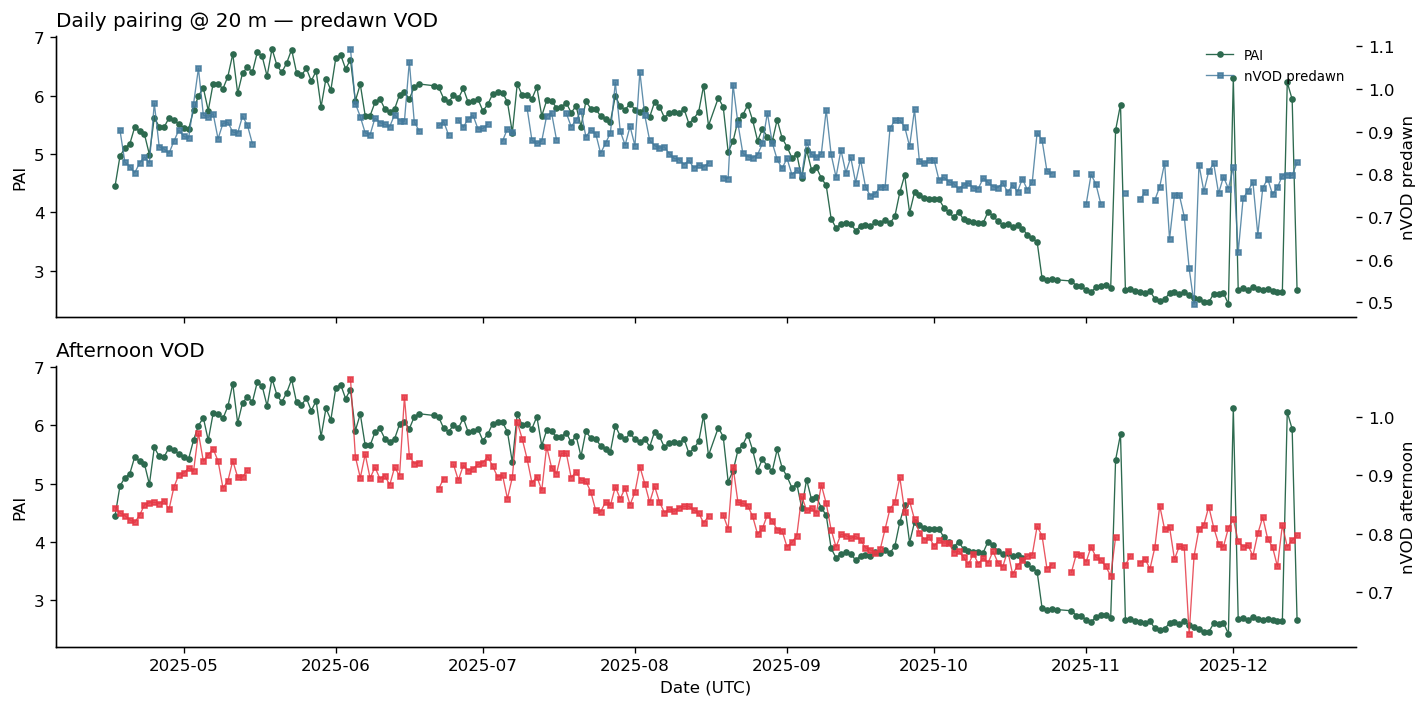

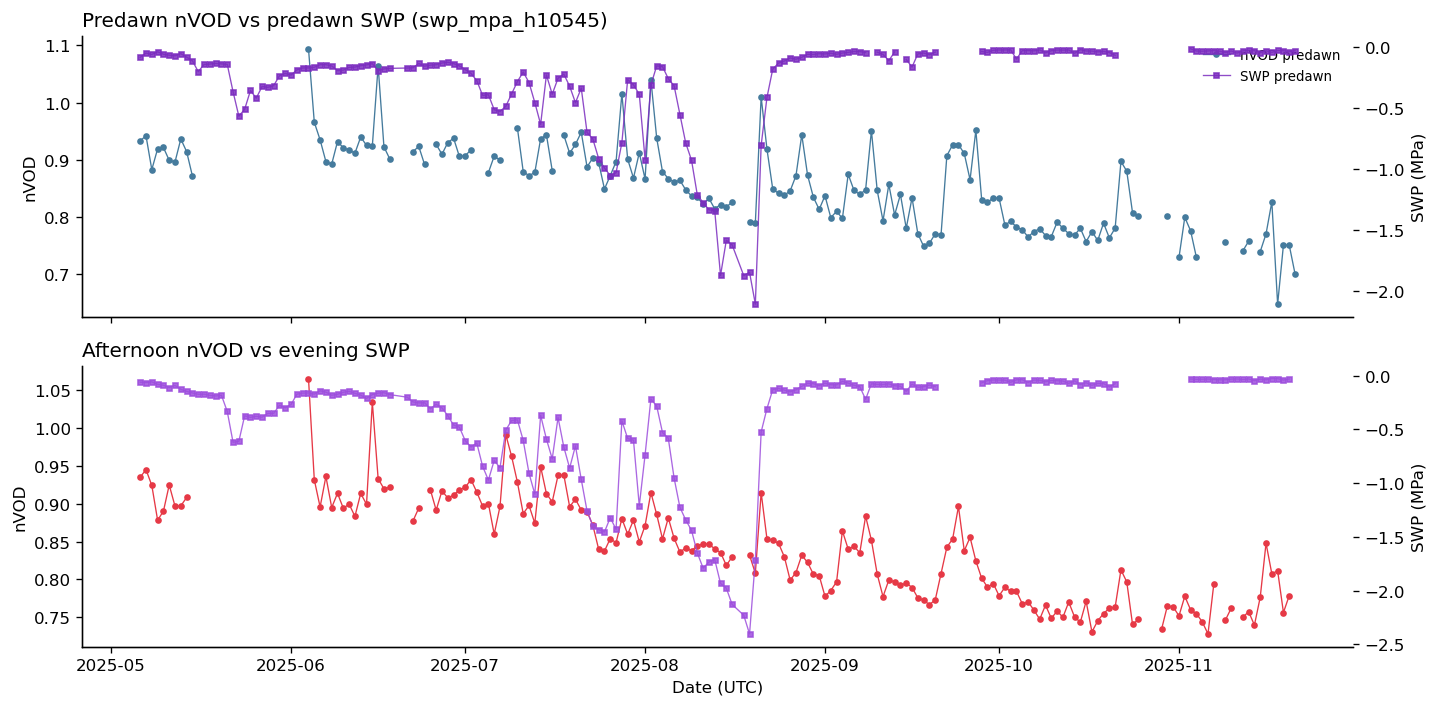

In [49]:
# Time series: PAI vs predawn / afternoon nVOD (joint-filter days highlighted)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

tpre = merged_pre.sort_values("date")
taft = merged_aft.sort_values("date")

ax = axes[0]
ax.plot(tpre["date"], tpre["pai"], "o-", ms=3, lw=0.8, color="#2d6a4f", label="PAI")
ax.set_ylabel("PAI")
ax2 = ax.twinx()
ax2.plot(tpre["date"], tpre["nvod_predawn"], "s-", ms=3, lw=0.8, color="#457b9d", alpha=0.85, label="nVOD predawn")
ax2.set_ylabel("nVOD predawn")
ax.set_title(f"Daily pairing @ {REFERENCE_HEIGHT:g} m — predawn VOD", loc="left")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)

ax = axes[1]
ax.plot(taft["date"], taft["pai"], "o-", ms=3, lw=0.8, color="#2d6a4f", label="PAI")
ax.set_ylabel("PAI")
ax2 = ax.twinx()
ax2.plot(taft["date"], taft["nvod_afternoon"], "s-", ms=3, lw=0.8, color="#e63946", alpha=0.85, label="nVOD afternoon")
ax2.set_ylabel("nVOD afternoon")
ax.set_title("Afternoon VOD", loc="left")

axes[-1].set_xlabel("Date (UTC)")
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
t1 = nvod_swp_pre.sort_values("date")
t2 = nvod_swp_aft_eve.sort_values("date")

ax = axes2[0]
ax.plot(t1["date"], t1["nvod_predawn"], "o-", ms=3, lw=0.8, color="#457b9d", label="nVOD predawn")
ax.set_ylabel("nVOD")
ax2 = ax.twinx()
ax2.plot(t1["date"], t1["swp_predawn_mpa"], "s-", ms=3, lw=0.8, color="#7b2cbf", alpha=0.85, label="SWP predawn")
ax2.set_ylabel("SWP (MPa)")
ax.set_title(f"Predawn nVOD vs predawn SWP ({SWP_MEAS_COL})", loc="left")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)

ax = axes2[1]
ax.plot(t2["date"], t2["nvod_afternoon"], "o-", ms=3, lw=0.8, color="#e63946", label="nVOD afternoon")
ax.set_ylabel("nVOD")
ax2 = ax.twinx()
ax2.plot(t2["date"], t2["swp_evening_mpa"], "s-", ms=3, lw=0.8, color="#9d4edd", alpha=0.85, label="SWP evening")
ax2.set_ylabel("SWP (MPa)")
ax.set_title("Afternoon nVOD vs evening SWP", loc="left")

axes2[-1].set_xlabel("Date (UTC)")
plt.tight_layout()
plt.show()

In [50]:
# Optional export for downstream stats (all paired days + QC flags)
exp = merged_pre.merge(
    merged_aft[["date", "nvod_afternoon", "vod_afternoon_window_ok", "use_afternoon",
                "precip_afternoon_mm", "rh_max_afternoon"]],
    on="date",
    how="outer",
)


def _prefix_cols(df: pd.DataFrame, prefix: str, key: str = "date") -> pd.DataFrame:
    return df.rename(columns={c: (c if c == key else f"{prefix}{c}") for c in df.columns})


exp = exp.merge(_prefix_cols(nvod_swp_pre, "nvodswp_pre__"), on="date", how="outer")
exp = exp.merge(_prefix_cols(nvod_swp_aft_eve, "nvodswp_ae__"), on="date", how="outer")
OUT = PROC / "proximal_rs" / "leaf_vod_pairs_2025.csv"
exp.to_csv(OUT, index=False)
print("Saved", OUT, "rows", len(exp))

Saved /mnt/data/lk1167/projects/dehar-spac/data/processed/proximal_rs/leaf_vod_pairs_2025.csv rows 237


## PAI-structured nVOD correction (evening window) & SWP validation

**Motivation.** nVOD responds to canopy water and to structure (PAI). When leaves are shed, PAI and nVOD can co-move without a change in tissue water status. We fit a **season-long** linear relationship between **evening nVOD** (19:00–20:59 UTC, aligned with the ~20:00 LEAF scan) and **LEAF total PAI**, then use the residual as a structure-adjusted signal.

**Total PAI.** `WeightedPAI` is a **cumulative** profile with height; the value at the canopy top is **`max(WeightedPAI)` per scan** (not the sum over layers — summing would over-count a cumulative profile).

**QC.** Same spirit as above: `quality_good` for the LEAF scan, and no rain / RH exceedance in the **19–21 UTC** window used for nVOD (same window as `swp_evening_met`).

**Steps.** (1) OLS: `nVOD_evening ~ PAI_total` on all passing days in the season. (2) `nVOD_structural = β₀ + β₁ PAI`. (3) `nVOD_residual = nVOD_obs − nVOD_structural`. (4) Compare Pearson **r** between **predawn SWP** (04–06 UTC mean, with its own met window) and raw evening nVOD vs residual — subset where evening-VOD + LEAF + predawn-SWP windows all pass QC.

Evening nVOD ~ PAI_total (OLS on n=131 days passing LEAF + 19–21 UTC met): slope=0.04812, intercept=0.5949, r=0.832, p=9.42e-35

Predawn SWP vs evening nVOD (joint QC, n=34):
  r(raw nVOD, SWP)     = +0.148  (p=4.02e-01)
  r(residual, SWP)     = +0.571  (p=4.26e-04)
  Δr (residual − raw)  = +0.422


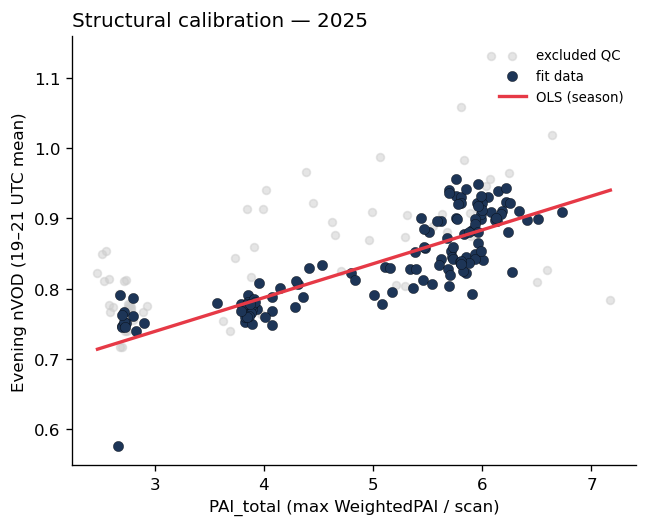

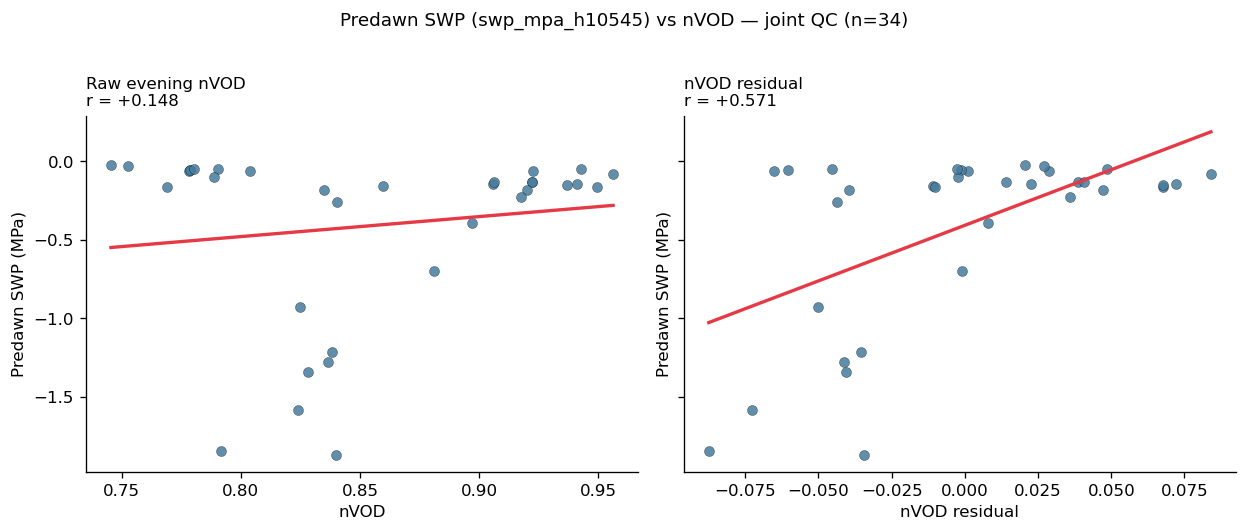

In [51]:
from scipy.stats import linregress, pearsonr

# --- Daily evening nVOD (19–21 UTC) from 30 min stack ---
v30 = vod_30[vod_30.index.year == YEAR].copy()
m_eve = _hour_mask(v30.index, EVENING_VOD_LEAF_HOURS)
_s_eve = v30.loc[m_eve, NVOD_30MIN_COL].dropna()
nvod_eve = (
    _s_eve.groupby(_s_eve.index.normalize()).mean().rename("nvod_evening_mean")
)

# --- LEAF @ SCAN_HOUR: total PAI = max cumulative WeightedPAI over the profile ---
lf_sc = leaf[(leaf["datetime"].dt.year == YEAR) & (leaf["scan_hour"] == SCAN_HOUR)].copy()
pai_scan = (
    lf_sc.groupby("datetime", sort=False)
    .agg(
        pai_total=(PAI_COL, "max"),
        quality_good=("quality_good", "first"),
    )
    .reset_index()
)
pai_scan["date"] = pd.to_datetime(pai_scan["datetime"], utc=True).dt.normalize()

pvc = pai_scan.merge(nvod_eve.rename_axis("date").reset_index(), on="date", how="inner")
pvc = pvc.merge(
    swp_evening_met[["window_ok", "precip_sum_mm", "rh_max"]].rename(
        columns={
            "window_ok": "evening_1921_window_ok",
            "precip_sum_mm": "precip_evening_1921_mm",
            "rh_max": "rh_max_evening_1921",
        }
    ),
    left_on="date",
    right_index=True,
    how="left",
)
pvc["use_evening_leaf_vod"] = pvc["quality_good"] & pvc["evening_1921_window_ok"].fillna(
    False
)

# --- Season OLS (structural nVOD) ---
fit_mask = (
    pvc["use_evening_leaf_vod"]
    & pvc["nvod_evening_mean"].notna()
    & pvc["pai_total"].notna()
)
fit_df = pvc.loc[fit_mask]
lr = linregress(fit_df["pai_total"].to_numpy(float), fit_df["nvod_evening_mean"].to_numpy(float))
slope, intercept, r_fit, p_fit = lr.slope, lr.intercept, lr.rvalue, lr.pvalue
pvc["nvod_structural"] = slope * pvc["pai_total"] + intercept
pvc["nvod_residual"] = pvc["nvod_evening_mean"] - pvc["nvod_structural"]

print(
    f"Evening nVOD ~ PAI_total (OLS on n={len(fit_df)} days passing LEAF + 19–21 UTC met): "
    f"slope={slope:.5f}, intercept={intercept:.4f}, r={r_fit:.3f}, p={p_fit:.2e}"
)

# --- Predawn SWP on same calendar date (04–06 UTC) + met window ---
swp_pre_df = swp_pre_daily.rename_axis("date").reset_index().merge(
    swp_predawn_met[["window_ok"]].rename(columns={"window_ok": "swp_predawn_window_ok"}),
    left_on="date",
    right_index=True,
    how="left",
)
val = pvc.merge(swp_pre_df, on="date", how="inner")
val["use_swp_compare"] = (
    val["use_evening_leaf_vod"]
    & val["swp_predawn_window_ok"].fillna(False)
    & val["swp_predawn_mpa"].notna()
    & val["nvod_evening_mean"].notna()
    & val["nvod_residual"].notna()
)
sub = val.loc[val["use_swp_compare"]]

def _safe_pearson(a, b):
    m = a.notna() & b.notna()
    if m.sum() < 3:
        return float("nan"), float("nan")
    r, p = pearsonr(a[m].to_numpy(float), b[m].to_numpy(float))
    return float(r), float(p)

r_raw, p_raw = _safe_pearson(sub["nvod_evening_mean"], sub["swp_predawn_mpa"])
r_res, p_res = _safe_pearson(sub["nvod_residual"], sub["swp_predawn_mpa"])
print(f"\nPredawn SWP vs evening nVOD (joint QC, n={len(sub)}):")
if p_raw == p_raw:
    print(f"  r(raw nVOD, SWP)     = {r_raw:+.3f}  (p={p_raw:.2e})")
else:
    print(f"  r(raw nVOD, SWP)     = {r_raw:+.3f}")
if p_res == p_res:
    print(f"  r(residual, SWP)     = {r_res:+.3f}  (p={p_res:.2e})")
else:
    print(f"  r(residual, SWP)     = {r_res:+.3f}")
if r_raw == r_raw and r_res == r_res:
    print(f"  Δr (residual − raw)  = {r_res - r_raw:+.3f}")

# --- Figures ---
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ok = pvc.loc[fit_mask]
ex = pvc.loc[~fit_mask & pvc["nvod_evening_mean"].notna() & pvc["pai_total"].notna()]
ax.scatter(ex["pai_total"], ex["nvod_evening_mean"], c="#cccccc", s=22, alpha=0.5, label="excluded QC")
ax.scatter(ok["pai_total"], ok["nvod_evening_mean"], c="#1d3557", s=38, edgecolors="k", linewidths=0.2, label="fit data")
xp = np.linspace(pvc["pai_total"].min(), pvc["pai_total"].max(), 100)
ax.plot(xp, slope * xp + intercept, color="#e63946", lw=2, label="OLS (season)")
ax.set_xlabel("PAI_total (max WeightedPAI / scan)")
ax.set_ylabel("Evening nVOD (19–21 UTC mean)")
ax.set_title(f"Structural calibration — {YEAR}", loc="left")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3), sharey=True)
titles_rs = [
    (axes[0], "nvod_evening_mean", f"Raw evening nVOD\nr = {r_raw:+.3f}"),
    (axes[1], "nvod_residual", f"nVOD residual\nr = {r_res:+.3f}"),
]
for ax, xcol, ttitle in titles_rs:
    ax.scatter(
        sub[xcol],
        sub["swp_predawn_mpa"],
        c="#457b9d",
        s=36,
        edgecolors="k",
        linewidths=0.2,
        alpha=0.85,
    )
    m = sub[xcol].notna() & sub["swp_predawn_mpa"].notna()
    if m.sum() >= 3:
        lr2 = linregress(sub.loc[m, xcol].to_numpy(float), sub.loc[m, "swp_predawn_mpa"].to_numpy(float))
        xs = np.linspace(sub.loc[m, xcol].min(), sub.loc[m, xcol].max(), 50)
        ax.plot(xs, lr2.intercept + lr2.slope * xs, color="#e63946", lw=2)
    ax.set_xlabel("nVOD" if xcol == "nvod_evening_mean" else "nVOD residual")
    ax.set_ylabel("Predawn SWP (MPa)")
    ax.set_title(ttitle, loc="left", fontsize=10)
fig.suptitle(
    f"Predawn SWP ({SWP_MEAS_COL}) vs nVOD — joint QC (n={len(sub)})",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()